In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aipeli/binance-ethusdt")

print("Path to dataset files:", path)

100%|██████████| 9.29M/9.29M [00:01<00:00, 6.48MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aipeli/binance-ethusdt/versions/1


In [3]:
import pandas as pd
import os

# Assuming 'path' from the previous cell contains the directory where the file was downloaded
file_path = os.path.join(path, "ethusdt_kline_1m.csv")  # Construct the correct path

# Load the dataset
df = pd.read_csv(file_path)

# Show basic info and the first few rows to understand the structure
df.info(), df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484287 entries, 0 to 484286
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   t       484287 non-null  int64  
 1   o       484287 non-null  float64
 2   h       484287 non-null  float64
 3   l       484287 non-null  float64
 4   c       484287 non-null  float64
 5   v       484287 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 22.2 MB


(None,
                t       o       h       l       c           v
 0  1609430400000  736.00  736.97  735.74  735.85  1376.74470
 1  1609430460000  735.75  735.93  733.60  733.79  1152.24573
 2  1609430520000  733.84  734.47  732.45  732.55  1453.18100
 3  1609430580000  732.55  733.41  732.47  732.65   667.83054
 4  1609430640000  732.66  733.64  732.16  733.25   621.82394)

In [4]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['t'], unit='ms')

# Set datetime as index
df.set_index('timestamp', inplace=True)

# Drop the original timestamp column
df.drop(columns='t', inplace=True)

# Resample to daily frequency using the last close price of each day
daily_df = df.resample('D').agg({
    'o': 'first',   # First open of the day
    'h': 'max',     # Max high
    'l': 'min',     # Min low
    'c': 'last',    # Last close of the day
    'v': 'sum'      # Total volume
})

# Drop any rows with missing values
daily_df.dropna(inplace=True)

daily_df.head()


,o,h,l,c,v
timestamp,,,,,
2020-12-31,736.00,745.00,724.48,736.42,1.843608e+05
2021-01-01,736.42,749.00,714.29,728.91,6.751141e+05
2021-01-02,728.91,787.69,714.91,774.56,1.352619e+06
2021-01-03,774.44,1011.07,768.71,978.28,2.813604e+06
2021-01-04,978.33,1162.97,890.00,1041.43,4.245011e+06


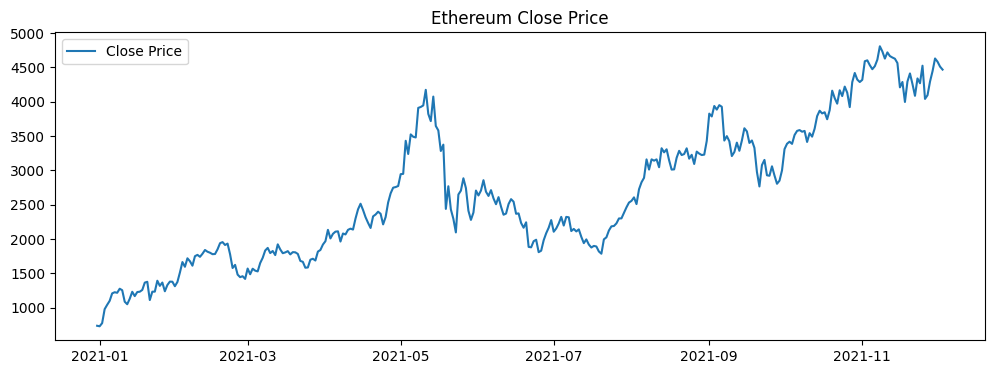

ADF Statistic: -1.3185153278143464
p-value: 0.6206595357567664
Critical Value (1%): -3.449962981927952
Critical Value (5%): -2.870180642420163
Critical Value (10%): -2.5713734527352607


In [5]:
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Use only the 'Close' price
close_series = daily_df['c']

# Plot original series
plt.figure(figsize=(12,4))
plt.plot(close_series, label='Close Price')
plt.title("Ethereum Close Price")
plt.legend()
plt.show()

# Perform ADF test
adf_result = adfuller(close_series)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
for key, value in adf_result[4].items():
    print(f'Critical Value ({key}): {value}')


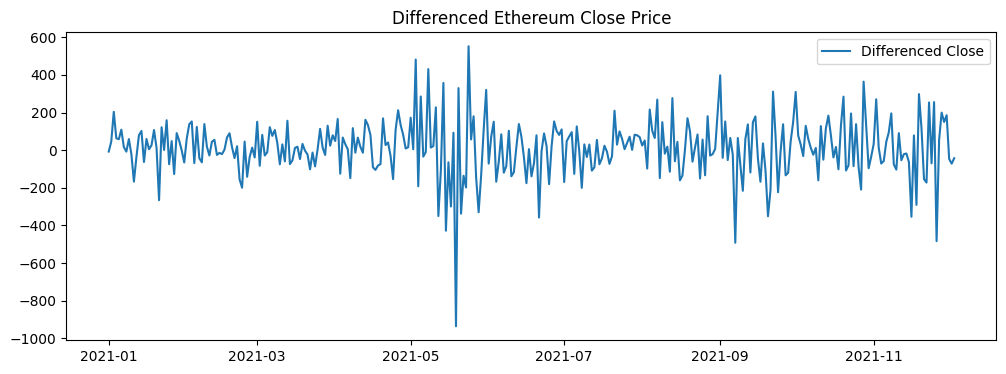

ADF Statistic (Differenced): -21.155893352026936
p-value: 0.0


In [6]:
# First-order differencing
diff_close = close_series.diff().dropna()

# Plot differenced series
plt.figure(figsize=(12,4))
plt.plot(diff_close, label='Differenced Close')
plt.title("Differenced Ethereum Close Price")
plt.legend()
plt.show()

# ADF test on differenced series
adf_result_diff = adfuller(diff_close)
print('ADF Statistic (Differenced):', adf_result_diff[0])
print('p-value:', adf_result_diff[1])


In [17]:
recent_data = close_series[-180:]  # Use last 180 days


In [18]:
diff_data = recent_data.diff().dropna()


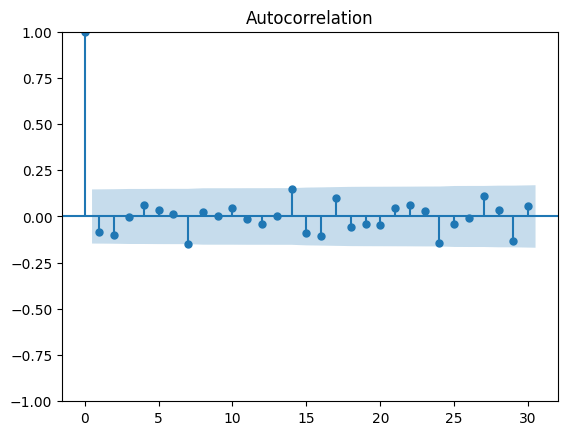

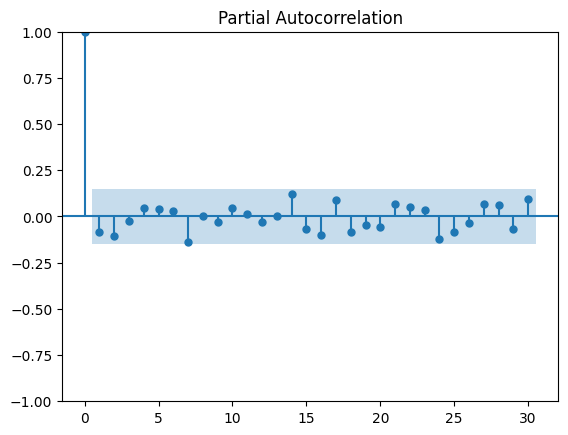

In [19]:
plot_acf(diff_data, lags=30)
plot_pacf(diff_data, lags=30)
plt.show()


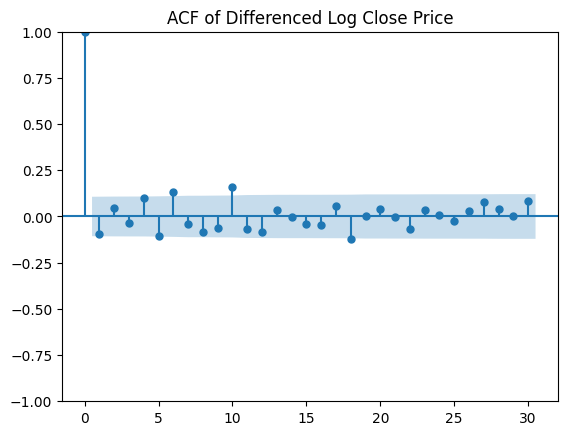

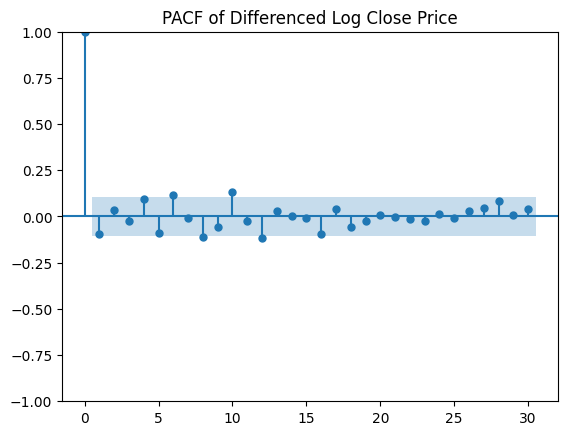

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(log_close_diff, lags=30)
plt.title("ACF of Differenced Log Close Price")
plt.show()

plot_pacf(log_close_diff, lags=30)
plt.title("PACF of Differenced Log Close Price")
plt.show()


In [20]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(recent_data, order=(1, 1, 2))  # adjust based on plots
model_fit = model.fit()
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                      c   No. Observations:                  180
Model:                 ARIMA(1, 1, 2)   Log Likelihood               -1143.387
Date:                Mon, 14 Apr 2025   AIC                           2294.773
Time:                        12:22:17   BIC                           2307.523
Sample:                    06-07-2021   HQIC                          2299.943
                         - 12-03-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0664      0.932     -0.071      0.943      -1.893       1.760
ma.L1         -0.0202      0.910     -0.022      0.982      -1.804       1.763
ma.L2         -0.0851      0.108     -0.789      0.4

In [21]:
forecast = model_fit.get_forecast(steps=30)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()


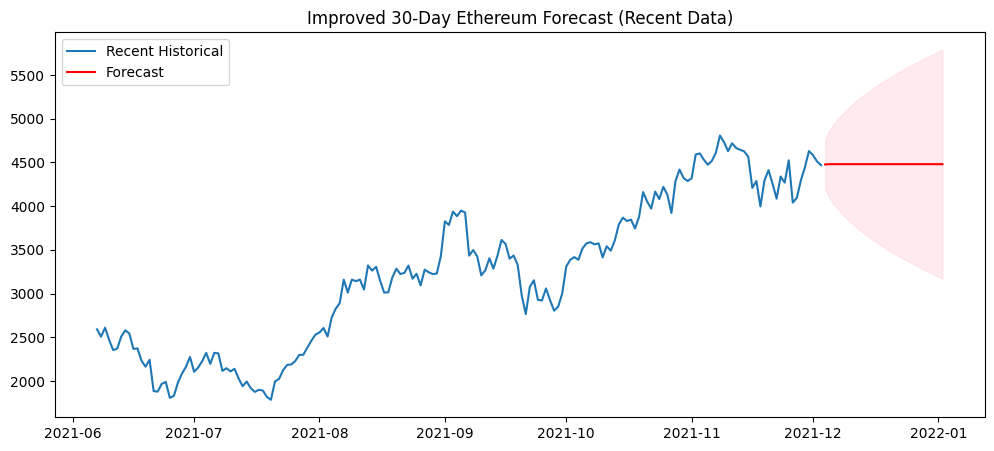

In [22]:
plt.figure(figsize=(12,5))
plt.plot(recent_data, label='Recent Historical')
plt.plot(forecast_mean, color='red', label='Forecast')
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 color='pink', alpha=0.3)
plt.title("Improved 30-Day Ethereum Forecast (Recent Data)")
plt.legend()
plt.show()
